# 🚗 Road Lane Detection for Self-Driving Cars

This notebook implements a **classical computer vision pipeline** for detecting road lanes in real-time.  
It covers the full processing chain — from raw frames to annotated lane overlays.

**Libraries:** OpenCV · NumPy · Matplotlib  
**Techniques:** Canny Edge Detection · Hough Transform · ROI Masking · Line Averaging

---

## Pipeline Overview

```
Frame Input → Grayscale → Gaussian Blur → Canny Edges → ROI Mask → Hough Lines → Overlay
```

| Step | Function | Purpose |
|------|----------|---------|
| 1 | `preprocess_frame()` | Convert to grayscale + blur |
| 2 | `canny_edges()` | Detect strong intensity gradients |
| 3 | `region_of_interest()` | Mask out non-road area |
| 4 | `hough_lines()` | Detect line segments |
| 5 | `average_slope_intercept()` | Merge segments into clean lane lines |
| 6 | `display_lines()` | Draw overlay on original frame |

---
## Cell 1 — Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, HTML

# Notebook display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = [14, 5]
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['figure.facecolor'] = '#161b22'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.titlecolor']  = 'white'

print("✅ Libraries imported successfully")
print(f"   OpenCV version : {cv2.__version__}")
print(f"   NumPy  version : {np.__version__}")

✅ Libraries imported successfully
   OpenCV version : 4.13.0
   NumPy  version : 2.3.5


---
## Cell 2 — Core Pipeline Functions

In [2]:
def preprocess_frame(frame, blur_ksize=5):
    """
    Step 1: Convert BGR frame to grayscale and apply Gaussian blur.
    
    Args:
        frame      : Input BGR image (numpy array)
        blur_ksize : Kernel size for Gaussian blur (must be odd)
    Returns:
        blurred    : Grayscale blurred image
    """
    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    return blurred


def canny_edges(img, low_thresh=50, high_thresh=150):
    """
    Step 2: Detect edges using Canny algorithm.
    Ratio rule-of-thumb: high_thresh = 2x or 3x low_thresh
    
    Args:
        img          : Grayscale image
        low_thresh   : Lower hysteresis threshold
        high_thresh  : Upper hysteresis threshold
    Returns:
        edges        : Binary edge map
    """
    return cv2.Canny(img, low_thresh, high_thresh)


def region_of_interest(edges, vertices):
    """
    Step 3: Keep only edges inside a polygonal ROI.
    
    Args:
        edges    : Binary edge map
        vertices : numpy array of polygon corners  shape=(1, N, 2)
    Returns:
        masked   : Edges inside ROI only
    """
    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, vertices, 255)
    return cv2.bitwise_and(edges, mask)


def hough_lines(masked, rho=2, theta=np.pi/180,
                threshold=100, min_line_len=40, max_line_gap=5):
    """
    Step 4: Detect line segments via Probabilistic Hough Transform.
    
    Args:
        masked        : ROI-masked edge map
        rho           : Distance resolution in pixels
        theta         : Angle resolution in radians
        threshold     : Minimum votes for a line
        min_line_len  : Minimum segment length in pixels
        max_line_gap  : Maximum gap between segments
    Returns:
        lines         : Array of line segments [[x1,y1,x2,y2], ...]
    """
    return cv2.HoughLinesP(
        masked, rho, theta, threshold,
        np.array([]), min_line_len, max_line_gap
    )


def make_coordinates(frame, line_params):
    """
    Convert slope-intercept params to pixel coordinates spanning ROI.
    
    Args:
        frame       : Original frame (used to get height)
        line_params : [slope, intercept]
    Returns:
        [x1, y1, x2, y2] pixel coordinates
    """
    slope, intercept = line_params
    h = frame.shape[0]
    y1 = h                       # bottom of frame
    y2 = int(h * (1 / 1.7))     # just above ROI top
    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return [x1, y1, x2, y2]


def average_slope_intercept(frame, lines):
    """
    Step 5: Separate left/right lanes by slope sign, then average each group.
    
    Args:
        frame : Original BGR frame
        lines : Raw Hough line segments
    Returns:
        averaged_lines : List of up to 2 [x1,y1,x2,y2] lane lines
    """
    left_fit  = []
    right_fit = []

    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        if x2 == x1:
            continue  # skip vertical lines (undefined slope)
        params = np.polyfit([x1, x2], [y1, y2], 1)  # [slope, intercept]
        slope = params[0]
        if slope < 0:
            left_fit.append(params)
        else:
            right_fit.append(params)

    averaged_lines = []
    for fit_group in [left_fit, right_fit]:
        if len(fit_group) > 0:
            avg = np.average(fit_group, axis=0)
            averaged_lines.append(make_coordinates(frame, avg))

    return averaged_lines


def display_lines(frame, lines, color=(0, 255, 100), thickness=8):
    """
    Step 6: Draw lane lines onto a blank canvas and blend with original frame.
    
    Args:
        frame     : Original BGR frame
        lines     : List of [x1,y1,x2,y2] lane lines
        color     : BGR line color (default: green)
        thickness : Line thickness in pixels
    Returns:
        combo     : Blended output frame
    """
    line_image = np.zeros_like(frame)
    if lines is not None:
        for x1, y1, x2, y2 in lines:
            cv2.line(line_image, (x1, y1), (x2, y2), color, thickness)
    combo = cv2.addWeighted(frame, 0.8, line_image, 1.0, 1)
    return combo


print("✅ All pipeline functions defined successfully")

✅ All pipeline functions defined successfully


---
## Cell 3 — Full Single-Frame Pipeline (Test on Image)

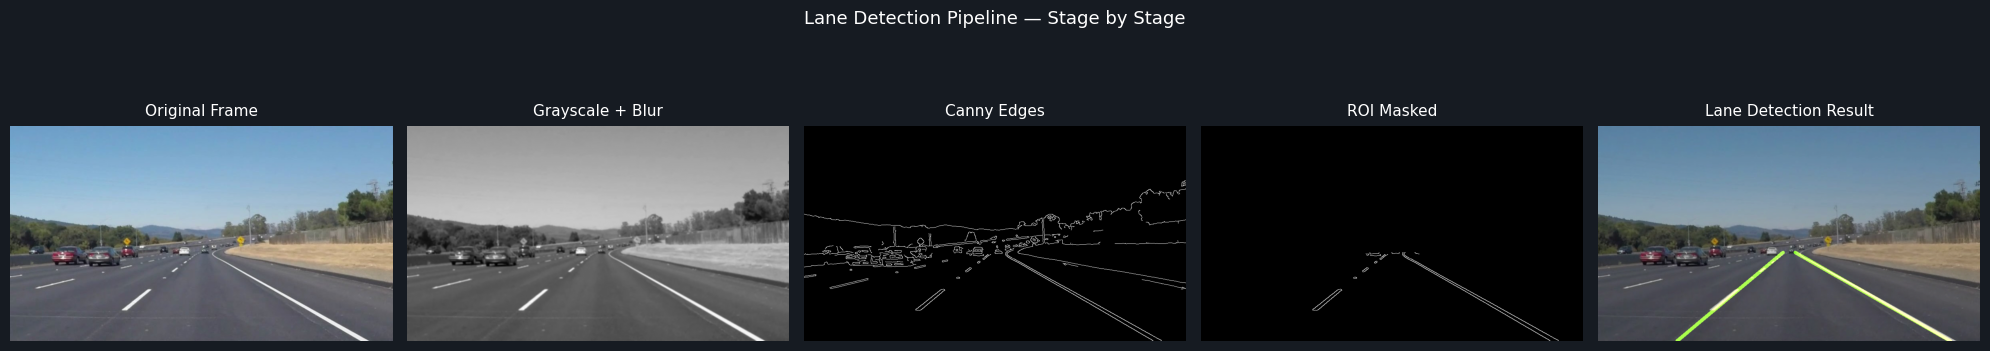

In [3]:
def detect_lanes(frame):
    """
    Full lane detection pipeline for a single frame.
    Runs all 6 steps and returns the annotated result.
    """
    h, w = frame.shape[:2]

    # --- Step 1: Preprocess ---
    preprocessed = preprocess_frame(frame, blur_ksize=5)

    # --- Step 2: Canny Edge Detection ---
    edges = canny_edges(preprocessed, low_thresh=50, high_thresh=150)

    # --- Step 3: Region of Interest ---
    roi_vertices = np.array([[
        (0,          h),
        (w // 2 - 60, int(h / 1.7)),
        (w // 2 + 60, int(h / 1.7)),
        (w,          h)
    ]], dtype=np.int32)
    masked_edges = region_of_interest(edges, roi_vertices)

    # --- Step 4: Hough Lines ---
    lines = hough_lines(masked_edges,
                        rho=2,
                        theta=np.pi / 180,
                        threshold=100,
                        min_line_len=40,
                        max_line_gap=5)

    if lines is None:
        print("⚠️  No lines detected in this frame.")
        return frame

    # --- Step 5: Average & Extrapolate ---
    lane_lines = average_slope_intercept(frame, lines)

    # --- Step 6: Draw Overlay ---
    result = display_lines(frame, lane_lines)

    return result, preprocessed, edges, masked_edges


# ── Test on a sample image ──────────────────────────────────────────────────
# Replace 'test_image.jpg' with your own road image path
image_path = 'test_image.jpg'

try:
    frame = cv2.imread(image_path)
    assert frame is not None, f"Could not load image: {image_path}"

    result, gray, edges, masked = detect_lanes(frame)

    # Convert BGR → RGB for matplotlib display
    stages = [
        (cv2.cvtColor(frame,  cv2.COLOR_BGR2RGB), 'Original Frame'),
        (gray,                                    'Grayscale + Blur'),
        (edges,                                   'Canny Edges'),
        (masked,                                  'ROI Masked'),
        (cv2.cvtColor(result, cv2.COLOR_BGR2RGB), 'Lane Detection Result'),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, (img, title) in zip(axes, stages):
        cmap = 'gray' if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=11, pad=8)
        ax.axis('off')
    plt.suptitle('Lane Detection Pipeline — Stage by Stage', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️  Image not found — place a road image at '{image_path}' to test.")
    print(f"    Error: {e}")
    print("    You can download a sample from:")
    print("    https://github.com/udacity/CarND-LaneLines-P1/tree/master/test_images")

---
## Cell 4 — Parameter Tuning (Visualization Grid)

Compare the effect of different **Canny threshold** combinations on edge detection quality.

C:\Users\maich\AppData\Local\Temp\ipykernel_21916\3067504853.py:26: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\maich\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


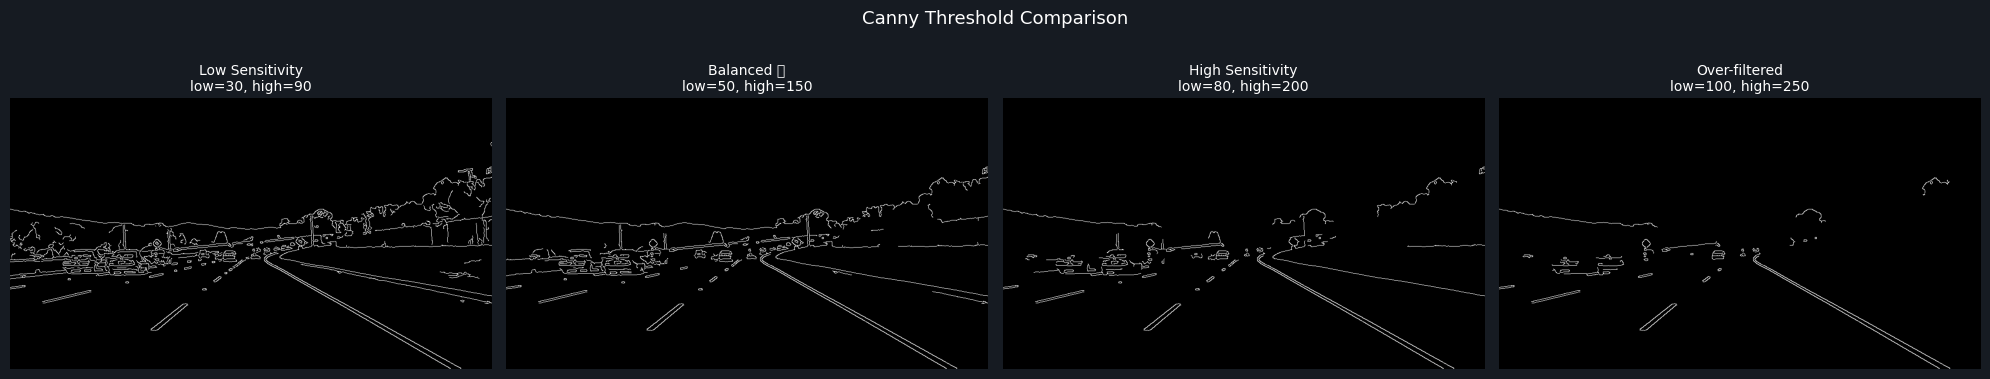

In [4]:
def compare_canny_params(frame_path, param_sets):
    """
    Visualize Canny edge detection with multiple threshold configurations.
    
    Args:
        frame_path  : Path to test image
        param_sets  : List of (low, high, label) tuples
    """
    frame = cv2.imread(frame_path)
    if frame is None:
        print(f"⚠️  Image not found: {frame_path}")
        return

    gray = preprocess_frame(frame, blur_ksize=5)

    n = len(param_sets)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for ax, (low, high, label) in zip(axes, param_sets):
        edges = canny_edges(gray, low_thresh=low, high_thresh=high)
        ax.imshow(edges, cmap='gray')
        ax.set_title(f'{label}\nlow={low}, high={high}', fontsize=10)
        ax.axis('off')

    plt.suptitle('Canny Threshold Comparison', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Parameter sets to compare
canny_configs = [
    (30,  90,  'Low Sensitivity'),
    (50,  150, 'Balanced ✅'),
    (80,  200, 'High Sensitivity'),
    (100, 250, 'Over-filtered'),
]

compare_canny_params('test_image.jpg', canny_configs)

---
## Cell 5 — Full Video Pipeline

Process a video file frame-by-frame and save the annotated output.

In [5]:
def process_video(input_path, output_path='lane_output.mp4'):
    """
    Process a full video: detect lanes on every frame and save result.
    
    Args:
        input_path  : Path to input video file
        output_path : Path for annotated output video
    """
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"⚠️  Cannot open video: {input_path}")
        return

    # Video properties
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"📹 Video: {width}×{height}  |  {fps:.1f} fps  |  {total} frames")
    print(f"💾 Output: {output_path}")

    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count   = 0
    lanes_detected = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        try:
            result, _, _, _ = detect_lanes(frame)
            out.write(result)
            lanes_detected += 1
        except Exception:
            out.write(frame)  # write original if detection fails

        frame_count += 1
        if frame_count % 100 == 0:
            pct = 100 * frame_count / total
            print(f"   [{pct:5.1f}%] Processed {frame_count}/{total} frames")

    cap.release()
    out.release()

    print(f"\n✅ Done! {lanes_detected}/{frame_count} frames with lane detection.")
    print(f"   Saved to: {output_path}")


# ── Run ─────────────────────────────────────────────────────────────────────
# Replace with your video path
process_video('road_video.mp4', output_path='lane_output.mp4')

📹 Video: 1280×720  |  50.0 fps  |  1295 frames
💾 Output: lane_output.mp4
   [  7.7%] Processed 100/1295 frames
   [ 15.4%] Processed 200/1295 frames
   [ 23.2%] Processed 300/1295 frames
   [ 30.9%] Processed 400/1295 frames
   [ 38.6%] Processed 500/1295 frames
   [ 46.3%] Processed 600/1295 frames
   [ 54.1%] Processed 700/1295 frames
   [ 61.8%] Processed 800/1295 frames
   [ 69.5%] Processed 900/1295 frames
   [ 77.2%] Processed 1000/1295 frames
   [ 84.9%] Processed 1100/1295 frames
   [ 92.7%] Processed 1200/1295 frames

✅ Done! 1295/1295 frames with lane detection.
   Saved to: lane_output.mp4


---
## Summary

| Component | Method | Key Parameters |
|-----------|--------|----------------|
| Noise Reduction | Gaussian Blur | `ksize=5` |
| Edge Detection | Canny | `low=50, high=150` |
| ROI | Trapezoid Mask | Bottom 60% of frame |
| Line Detection | Probabilistic Hough | `threshold=100, minLen=40` |
| Lane Averaging | Slope + Intercept Fit | `np.polyfit` |
| Overlay | Weighted Blend | `alpha=0.8, beta=1.0` |

### Next Steps
- Replace static ROI with **perspective transform** (bird's-eye view)
- Use **RANSAC** instead of simple averaging for outlier-robust fitting
- Integrate **deep learning** (LaneNet, SCNN) for curved lane handling
- Add **Kalman filter** for temporal smoothing across frames

---
*Computer Vision Project — Self-Driving Cars*